<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSGE603130 • Kecerdasan Artifisial dan Sains Data Dasar

Semester Gasal 2023/2024

Fakultas Ilmu Komputer, Universitas Indonesia

# *Proyek Akhir KASDAD Kelompok Data+*: Valorant Pro Matches (VPM)


## Kelompok
| Nama | NPM |
|---|---|
| Lyzander Marciano Andrylie | 2106750755 |
| Muhammad Hafizha Dhiyaulhaq | 2106750723 |
| Felix Tjahyadi | 2106638614 |

 

## Deskripsi Proyek Akhir

**Valorant** adalah ***5v5 team-based first-person tactical hero shooter*** yang dikembangkan dan dipublikasikan oleh Riot Games. Pada game ini, pemain akan menggunakan salah satu ***agent***/karakter dengan kemampuan unik. Masing-masing *agent* akan memiliki peran tertentu dalam tim: *Duelists*, *Sentinels*, *Initiators*, and *Controllers*.

Pada saat permainan dimulai, 5 pemain dalam 1 tim akan berperan sebagai tim penyerang dan 5 pemain lainnya dalam 1 tim akan berperan sebagai tim bertahan secara bergiliran. Tim penyerang menang pada suatu ronde jika dan hanya jika *spike* yang ditanam pada lokasi bom meledak dan/atau kelima pemain dari tim bertahan berhasil dikalahkan. Di sisi lain, Tim bertahan menang pada suatu ronde jika dan hanya jika *spike* yang telah ditanam pada lokasi bom berhasil dijinakkan, kelima pemain dari tim penyerang berhasil dikalahkan dengan *spike* yang tidak meledak, atau waktu ronde habis. Berkaitan dengan permainan, suatu permainan akan berlangsung dalam 13 ronde atau lebih jika belum memenuhi kondisi *win by two*. Suatu permainan dimenangkan oleh suatu tim jika dan hanya jika tim memenangkan 13 ronde atau lebih dengan selisih kemenangan 2 ronde atau lebih dari tim yang kalah sedemikian hingga kondisi *win by two* terpenuhi. 

Seiring dengan meningkatnya kepopuleran dari Valorant, Valorant memiliki kancah esports yang aktif. Pada kancah ini, banyak turnamen yang telah diselenggarakan dan diikuti oleh berbagai tim dari belahan dunia dengan hadiah kemenangan yang besar. Dengan demikian, pada proyek ini, kami ingin menganalisis data pertandingan dari *Valorant Pro Matches* dan membuat model *machine learning* yang sesuai. Berikut adalah ketentuan model machine learning yang akan dibuat.

-  Lakukan klasifikasi untuk menentukan Agent yang digunakan oleh setiap pemain pada setiap babak!
-  Buatlah model untuk memprediksi nilai rata-rata ACS dari masing-masing tim untuk sebuah pertandingan!
-  Lakukan clustering pada dataset, dan berikan analisis dan insight yang kaliat dapatkan dari cluster yang dibuat.

## Dependesi Proyek

### Import Libraries

In [1]:
import warnings
import random
from datetime import datetime
import re
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# sns color palette
palette_agent_role = {
    "duelists": "#FF4654",
    "initiators": "#5B4E77",
    "controllers": "#64A0B3",
    "sentinels": "#FFB94E",
}

# Remove warning
warnings.simplefilter(action='ignore', category=FutureWarning)

### Utility Function

In [2]:
def merge_datasets(df_matches, df_games, df_scores):
    df_matches_games = pd.merge(df_matches, df_games, on=['MatchID', 'Team1ID', 'Team2ID'])
    df_matches_games_scores = pd.merge(df_matches_games, df_scores, on=['GameID'])
    return df_matches_games_scores

class Transformer:
    def transform(self, data: pd.DataFrame):
        '''
        Implementasi berupa prosedur (Facade pattern) untuk men-transform test dataset `*_test.csv` ke dalam
        bentuk yang dapat diproses secara langsung oleh model machine learning yang telah dibuat.
        '''
        pass


class MatchesUtils(Transformer):
    '''
    Utility class untuk dataset `matches.csv`
    '''

    def transform(self, data: pd.DataFrame):
        pass

    def patch_transform(self, df: pd.DataFrame):
        def patch_transform(x):
            regex = r"(?<=Patch\s)\d"
            match = re.search(regex, x)
            return match.group() if match else x

        df['Patch'] = df['Patch'].map(patch_transform, na_action='ignore')

    def patch_impute(self, df_matches: pd.DataFrame, df_patch_date_range: pd.DataFrame):
        '''
        Imputasi Kolom `Patch` berdasarkan tanggal `Date` dari suatu pertandingan
        '''

        def patch_imputer(row):
            if not pd.isna(row['Patch']):
                return row['Patch']

            row_date_obj = datetime.strptime(row['Date'], "%Y-%m-%d")

            # Pengecekan `Date` berdasarkan nilai paling min
            lowest_patch_min_date = df_patch_date_range['Date']['min'].min()
            lowest_patch_min_date_obj = datetime.strptime(
                lowest_patch_min_date, "%Y-%m-%d")

            if row_date_obj < lowest_patch_min_date_obj:
                return df_patch_date_range['Date']['min'].idxmin()

            # Pengecekan `Date` berdasarkan range `df_patch_date_range`
            for patch, date_range in df_patch_date_range.iterrows():
                patch_min_date = date_range['Date']['min']
                patch_max_date = date_range['Date']['max']

                patch_min_date_obj = datetime.strptime(
                    patch_min_date, "%Y-%m-%d")
                patch_max_date_obj = datetime.strptime(
                    patch_max_date, "%Y-%m-%d")

                # Pengecekan `Date` dari suatu pertandingan untun menentukan Patch
                if patch_min_date_obj <= row_date_obj <= patch_max_date_obj:
                    return patch

            return row['Patch']

        df_matches['Patch'] = df_matches[['Date', 'Patch']].apply(
            patch_imputer, axis='columns')

    def date_impute(self, df: pd.DataFrame):
        def date_imputer(x):
            date, *_ = x.split()
            return date

        df['Date'] = df['Date'].map(date_imputer, na_action='ignore')


class GamesUtils(Transformer):
    '''
    Utility class untuk dataset `games.csv`
    '''

    def transform(self, data: pd.DataFrame):
        pass


class ScoresUtils(Transformer):
    '''
    Utility class untuk dataset `scores.csv`
    '''

    def transform(self, data: pd.DataFrame):
        pass

    def cek_null(self, df:pd.DataFrame):
        col_na = df.isnull().sum().sort_values(ascending=False)
        percent = col_na / len(df) * 100

        missing_data = pd.concat([col_na, percent], axis=1, keys=['Total', 'Percent'])
        print(missing_data[missing_data['Total'] > 0])

    def player_id_impute(self, df: pd.DataFrame):
        id_counter = df['PlayerID'].max() + 1
        player_ids = {}

        def player_id_imputer(row):
            nonlocal id_counter, player_ids

            if pd.isnull(row['PlayerID']):
                if row['PlayerName'] in player_ids:
                    return player_ids[row['PlayerName']]

                player_ids[row['PlayerName']] = id_counter
                id_counter += 1
                return player_ids[row['PlayerName']]

            return row['PlayerID']

        df['PlayerID'] = df[['PlayerID', 'PlayerName']].apply(
            player_id_imputer, axis='columns')

    def agent_impute(self, df: pd.DataFrame, df_merge, srs_most_used_hero_by_player):
        random.seed(1000)
        df_game_id_patch = df_merge[['GameID', 'Patch']]

        def agent_imputer(row):
            patch_nums = df_game_id_patch.loc[df_game_id_patch['GameID'] == row['GameID'], 'Patch']

            if (not pd.isnull(row['Agent'])) or len(patch_nums) == 0:
                return row['Agent']
            
            # Imputasi berdasarkan agent yang paling sering dimainkan
            agent = srs_most_used_hero_by_player[row['PlayerID'], patch_nums.iloc[0]]

            if isinstance(agent, str):
                return agent
            elif isinstance(agent, np.ndarray) and len(agent) >= 2:
                return agent[random.randint(0, len(agent)-1)]

            return row['Agent']

        df['Agent'] = df[['PlayerID', 'Agent', 'GameID']].apply(
            agent_imputer, axis='columns')
    
    def acs_impute(self, df_scores: pd.DataFrame, acs_median: pd.DataFrame):
        '''
        Imputasi Kolom 'ACS' berdasarkan Agent yang dipilih
        '''
        def acs_imputer(row):
            if not pd.isna(row['ACS']):
                return row['ACS']
            
            row_agent_obj = row['Agent']
            
            # # Pengecekan Agent untuk menentukan nilai ACS
            agent_row = acs_median.loc[acs_median['Agent'] == row_agent_obj]

            if not agent_row.empty:
                return agent_row['ACS'].iloc[0]
                
            return row['ACS']
        
        df_scores['ACS'] = df_scores[['Agent','ACS']].apply(acs_imputer, axis='columns')
   

# Objek utility
util_matches = MatchesUtils()
util_games = GamesUtils()
util_scores = ScoresUtils()

## Dataset

### Deskripsi Dataset

#### Dataset `matches.csv`

Berisi informasi tentang tim yang berpartisipasi dalam sebuah turnamen. Pertandingan umumnya diadakan dengan aturan "best of 3," di mana tim yang memenangkan babak terbanyak akan menjadi pemenang pertandingan.

> **Note:** Pertandingan final diadakan dengan aturan "best of 5"

Jumlah Kolom x Baris: 12 kolom x 6401 baris

Deskripsi Kolom:

1. MatchID : Id pertandingan
2. Date : Tanggal pertandingan
3. Patch : Versi Valorant saat pertandingan dilakukan
4. EventID : Id turnamen
5. EventName : Nama turnamen
6. EventStage : Tahap turnamen
7. Team1ID : Id tim 1
8. Team2ID : Id tim 2
9. Team1 : Nama tim 1
10. Team2 : Nama tim 2
11. Team1_MapScore : Banyak babak yang dimenangkan tim 1
12. Team2_MapScore : Banyak babak yang dimenangkan tim 2

#### Dataset `games.csv`

Mendokumentasikan detail babak yang dimainkan oleh kedua tim yang bersaing dalam turnamen.

Jumlah Kolom x Baris: 18 kolom x 12961 baris

Deskripsi Kolom:

1. GameID : Id babak
2. MatchID : Id pertandingan
3. Map : Peta yang digunakan
4. Team1ID : Id tim 1
5. Team2ID : Id tim 2
6. Team1 : Nama tim 1
7. Team2 : Nama tim 2
8. Winner : Tim yang menjadi pemenang
9. Team1_Eco : Banyak ronde eco yang dilakukan tim 1
10. Team1_SemiEco : Banyak ronde semi eco yangdilakukan tim 1
11. Team1_SemiBuy : Banyak ronde semi buy yangdilakukan tim 1
12. Team1_FullBuy : Banyak ronde full buy yang dilakukan tim 1
13. Team1_TotalRounds : Banyak ronde yang dimenangkan tim 1
14. Team2_Eco : Banyak ronde eco yang dilakukan tim 2
15. Team2_SemiEco : Banyak ronde semi eco yang dilakukan tim 2
16. Team2_SemiBuy : Banyak ronde semi buy yang dilakukan tim 2
17. Team2_FullBuy : Banyak ronde full buy yang dilakukan tim 2
18. Team2_TotalRounds : Banyak ronde yang dimenangkan tim 2

> **Note:** Valorant Economy Guide: <https://www.ign.com/wikis/valorant/Valorant_Economy_Guide>
> Penting untuk tahap pemahaman data.

#### Dataset `scores.csv`

Merupakan catatan akhir dari status para pemain profesional yang bertanding dalam babak tersebut

Jumlah Kolom x Baris: 28 kolom x 128779 baris

Deskripsi Kolom:

1. GameID : Id babak
2. PlayerID: Id pemain
3. PlayerName : Username pemain
4. TeamAbbreviation : Singkatan nama tim
5. Agent : Agent/karakter yang digunakan
6. ACS : Skor rata-rata dari pemain
7. Kills : Jumlah musuh yang dikalahkan
8. Deaths : Total pemain berhasil dieliminasi
9. Assists : Jumlah kontribusi pemain dalam membantu rekannya untuk mengalahkan musuh
10. PlusMinus : Selisih antara jumlah mengalahkan musuh (Kills) dan jumlah tereliminasi (Deaths)
11. KAST_Percent : Besar kontribusi pemain dalam pertandingan
12. ADR : Rata-rata serangan yang diberikan oleh pemain ke pihak musuh
13. HS_Percent : Persentase serangan yang diberikan mengenai kepala musuh
14. FirstKills : Total pemain berhasil melakukan eliminasi pertama kali pada suatu ronde
15. FirstDeaths : Total pemain dieliminasi pertama kali pada suatu ronde
16. FKFD_PlusMinus : Selisih antara jumlah First Kills dan First Deaths
17. Num_2Ks, Num_3ks, Num_4ks, Num_5ks : Jumlah pemain berhasil mengeliminasi X musuh dalam suatu ronde
18. OnevOne, OnevTwo, OnevThree, OnevFour, OnevFive : Jumlah pemain berhasil mengalahkan X musuh pada suatu timeframe
19. Econ : Besar serangan yang dihasilkan untuk setiap 1000 creds (mata uang pada permainan) yang digunakan untuk membeli perlengkapan
20. Plants : Jumlah pemain berhasil menanam spike (bom) pada suatu ronde
21. Defuses : Jumlah pemain berhasil menjinakkan spike (bom) pada suatu ronde

> **Notes:** Valorant Key Metric: <https://digitalgamersdream.com/key-metrics-for-analyzing-valorant-matches/>
> Penting untuk pemahaman terkait metric-metric tertentu, seperti ACS (Average Combat Score) dan KAST.

> Num_5ks = Ace

#### Dataset `agent_encode.csv`

Label encoding dari nama agent di Valorant.

Jumlah Kolom x Baris: 2 kolom x 17 baris

Deskripsi Kolom:

1. Agent: nama karakter
2. Encode: hasil encoding

#### Dataset `agent_role.csv`

Kategori dari agent-agent pada valorant

Jumlah Kolom x Baris: 2 kolom x 17 baris

Deskripsi Kolom:

1. Agent: nama karakter
2. Role: peran karakter

Kategori Kolom Role:

1. controllers: agen-agen dengan tipe ini dapat memblokir area tertentu di peta untuk mempermudah serangan atau pertahanan, serta mengontrol alur permainan.
2. duelists: agen-agen dengan tipe ini bersifat ofensif dan unggul dalam pertarungan satu lawan satu yang bertujuan untuk menerobos pertahanan musuh dan memenangkan duel.
3. initiators: agen-agen dengan tipe ini berfungsi sebagai pendukung dan sangat cocok untuk memulai pertarungan dan membantu tim Anda memenangkannya. Agen ini biasanya memiliki kemampuan yang memungkinkan mereka memberikan informasi kepada tim, atau mengacaukan musuh. 
4. sentinels: agen-agen dengan tipe ini bersifat defensif dan biasanya memperlambat, mengulur waktu, atau terkadang langsung menghentikan serangan musuh di area tertentu di peta.

### Read Dataset

#### Dataset `matches.csv`

In [3]:
df_matches = pd.read_csv('./dataset/matches.csv')
df_matches.head()

,No,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1,Team2,Team1_MapScore,Team2_MapScore
0,0,62393,2022-01-08 15:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,Pho Real,2,1
1,1,62403,2022-01-08 15:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (C),7046,7047,Bjor's Kittens,Mugiwara,2,0
2,2,62391,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (A),6461,6903,Akrew,Booster Seat Gaming,2,1
3,3,62396,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (B),6164,7043,Radiance,sameROFLMAO,2,0
4,5,62402,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Elimination (C),7047,3545,Mugiwara,CLG Red,2,0


In [4]:
df_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6401 entries, 0 to 6400
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   No              6401 non-null   int64 
 1   MatchID         6401 non-null   int64 
 2   Date            6401 non-null   object
 3   Patch           5990 non-null   object
 4   EventID         6401 non-null   int64 
 5   EventName       6401 non-null   object
 6   EventStage      6401 non-null   object
 7   Team1ID         6401 non-null   int64 
 8   Team2ID         6401 non-null   int64 
 9   Team1           6401 non-null   object
 10  Team2           6401 non-null   object
 11  Team1_MapScore  6401 non-null   int64 
 12  Team2_MapScore  6401 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 650.2+ KB


In [5]:
df_matches.duplicated().sum()

0

#### Dataset `games.csv`

In [6]:
df_games = pd.read_csv('./dataset/games.csv')
df_games.head()

,No,GameID,MatchID,Map,Team1ID,Team2ID,Team1,Team2,Winner,Team1_Eco,Team1_SemiEco,Team1_SemiBuy,Team1_FullBuy,Team1_TotalRounds,Team2_Eco,Team2_SemiEco,Team2_SemiBuy,Team2_FullBuy,Team2_TotalRounds
0,0,60894,62393,Breeze,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,0.0,5.0,13.0,13,4.0,2.0,4.0,10.0,7
1,1,60895,62393,Bind,6903,6020,Booster Seat Gaming,Pho Real,2,3.0,3.0,5.0,4.0,2,2.0,0.0,4.0,9.0,13
2,2,60896,62393,Haven,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,2.0,5.0,12.0,13,2.0,2.0,6.0,11.0,8
3,3,60924,62403,Icebox,7046,7047,Bjor's Kittens,Mugiwara,1,2.0,2.0,4.0,11.0,13,4.0,1.0,2.0,12.0,6
4,4,60925,62403,Haven,7046,7047,Bjor's Kittens,Mugiwara,1,4.0,2.0,3.0,13.0,13,3.0,3.0,4.0,12.0,9


In [7]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12961 entries, 0 to 12960
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No                 12961 non-null  int64  
 1   GameID             12961 non-null  int64  
 2   MatchID            12961 non-null  int64  
 3   Map                12961 non-null  object 
 4   Team1ID            12961 non-null  int64  
 5   Team2ID            12961 non-null  int64  
 6   Team1              12961 non-null  object 
 7   Team2              12961 non-null  object 
 8   Winner             12961 non-null  int64  
 9   Team1_Eco          11927 non-null  float64
 10  Team1_SemiEco      11927 non-null  float64
 11  Team1_SemiBuy      11927 non-null  float64
 12  Team1_FullBuy      11927 non-null  float64
 13  Team1_TotalRounds  12961 non-null  int64  
 14  Team2_Eco          11927 non-null  float64
 15  Team2_SemiEco      11927 non-null  float64
 16  Team2_SemiBuy      119

In [8]:
df_games.duplicated().sum()

0

#### Dataset `scores.csv`

In [9]:
df_scores = pd.read_csv('./dataset/scores.csv')
df_scores.head()

,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,Num_4Ks,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses
0,0,60894,8419.0,Reduxx,Boos,jett,313.0,24.0,10.0,3.0,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0
1,1,60894,466.0,ChurmZ,Boos,chamber,227.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0
2,2,60894,3712.0,diaamond,Boos,sova,226.0,17.0,9.0,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0
3,3,60894,5099.0,Boltzy,Boos,viper,218.0,17.0,12.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0
4,4,60894,3983.0,Virtyy,Boos,skye,80.0,5.0,13.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0


In [10]:
df_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128779 entries, 0 to 128778
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   No                128779 non-null  int64  
 1   GameID            128779 non-null  int64  
 2   PlayerID          128692 non-null  float64
 3   PlayerName        128779 non-null  object 
 4   TeamAbbreviation  126763 non-null  object 
 5   Agent             124679 non-null  object 
 6   ACS               128249 non-null  float64
 7   Kills             128289 non-null  float64
 8   Deaths            128289 non-null  float64
 9   Assists           128289 non-null  float64
 10  PlusMinus         127026 non-null  float64
 11  KAST_Percent      2637 non-null    float64
 12  ADR               119904 non-null  float64
 13  HS_Percent        119307 non-null  float64
 14  FirstKills        128249 non-null  float64
 15  FirstDeaths       119314 non-null  float64
 16  FKFD_PlusMinus    11

In [11]:
df_scores.duplicated().sum()

0

#### Dataset Agent

##### Dataset `agent_encode.csv`

In [12]:
# Read and drop the first column
df_agent_encode = pd.read_csv('./dataset/agent_encode.csv')
df_agent_encode.drop(df_agent_encode.columns[0], axis='columns', inplace=True)
df_agent_encode.head()

,Agent,Encode
0,jett,0
1,sova,1
2,astra,2
3,kayo,3
4,killjoy,4


##### Dataset `agent_role.csv`

In [13]:
# Read and drop the first column
df_agent_role = pd.read_csv('./dataset/agent_role.csv')
df_agent_role.drop(df_agent_role.columns[0], axis='columns', inplace=True)
df_agent_role.head()

,Agent,Role
0,jett,duelists
1,sova,initiators
2,astra,controllers
3,kayo,initiators
4,killjoy,sentinels


##### Merge Dataset Agent

In [14]:
df_agent = pd.merge(df_agent_encode, df_agent_role)
df_agent

,Agent,Encode,Role
0,jett,0,duelists
1,sova,1,initiators
2,astra,2,controllers
3,kayo,3,initiators
4,killjoy,4,sentinels
5,skye,5,initiators
6,cypher,6,sentinels
7,viper,7,controllers
8,sage,8,sentinels
9,reyna,9,duelists


## Exploratory Data Analysis

### Distribusi Agent Berdasarkan Patch

#### Informasi Kolom `Patch`

In [15]:
df_matches['Patch'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6401 entries, 0 to 6400
Series name: Patch
Non-Null Count  Dtype 
--------------  ----- 
5990 non-null   object
dtypes: object(1)
memory usage: 50.1+ KB


##### Jumlah Null Value

In [16]:
df_matches['Patch'].isnull().sum()

411

##### Informasi Kategori

In [17]:
df_matches['Patch'].value_counts('Patch').sort_index(ascending=False)

Patch
Patch 3.12                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   0.028381
Patch 3.10                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

Perhatikan bahwa value pada kolom `Patch` tidak ringkas, sulit diinterpretasikan, sulit dipahami dan tidak konsisten. Dengan demikian, kita dapat melakukan *data cleaning* sedemikian hingga masalah-masalah pada kolom `Patch` dapat diatasi. 

#### Pemrosesan Kolom Patch

Pemrosesan kolom patch dapat dilakukan dengan memahami format dari nilai pada kolom `Patch`. Bentuk format `Patch` pada game valorant adalah `X.YZ` dengan makna sebagai berikut.

1. `X`: merepresentasikan nomor **episode** yang biasanya berlangsung selama 2 bulan
2. `Y`: merepresentasikan nomor **act** yang biasanya berlansung selama 2 minggu
3. `Z`: merepresentasikan nomor **patch** dalam suatu **act**

Dengan demikian, kita dapat meringkas data berdasarkan nilai `X` sedemikian hingga nilai pada kolom `Patch` mudah dipahami.

In [18]:
util_matches.patch_transform(df_matches)
df_matches['Patch'].value_counts()

Patch
3    2038
2    1959
1    1907
0      86
Name: count, dtype: int64

##### Cek Null Value

In [19]:
df_matches['Patch'].isnull().sum()

411

Perhatikan bahwa masih terdapat 411 pertandingan dengan kolom `Patch` bernilai null. Untuk memperbaiki hal ini, kita dapat melakukan *data imputation* berdasarkan tanggal pertandingan pada kolom `Date`. Hal ini dikarenakan pertandingan yang diselenggarakan pada rentang tanggal tertentu dapat ditentukan kolom `Patch`-nya berdasarkan data yang ada. 

##### Pemrosesan Kolom Date

In [20]:
util_matches.date_impute(df_matches)
df_matches['Date'].value_counts()

Date
2021-11-12    74
2021-11-13    69
2020-12-19    68
2021-07-22    48
2021-10-09    46
              ..
2021-12-16     1
2021-03-23     1
2021-06-01     1
2021-05-31     1
2020-07-21     1
Name: count, Length: 557, dtype: int64

Pemrosesan di atas dilakukan agar kolom `Date` dapat lebih mudah diproses untuk menentukan kolom `Patch` yang akan diimputasi berdasarkan kolom tersebut.

##### Rentang Tanggal Patch

In [21]:
df_patch_date_range = df_matches[['Patch', 'Date']].groupby('Patch').aggregate(['min', 'max'])
df_patch_date_range

Date            
              min         max
Patch                        
0      2020-05-04  2020-06-14
1      2020-06-04  2021-01-24
2      2021-01-13  2021-06-29
3      2021-06-22  2022-01-08

##### Imputasi Data untuk kolom `Patch`

In [22]:
util_matches.patch_impute(df_matches, df_patch_date_range)

Imputasi dilakukan pada baris dengan kolom `Patch` yang bernilai null. Nilai dari kolom tersebut akan ditentukan berdasarkan `Date` dari pertandingan. `Date` dari pertandingan akan dibandingkan dengan rentang tanggal patch (`df_patch_date_range`). Jika suatu pertandingan memiliki `Date` yang berada pada rentang `min Date` dan `max Date` dari suatu `Patch x`, maka kolom `Patch` akan bernilai `x`. Sebagai tambahan, pertandingan dengan `Date` \< `min Date` dari `Patch 0` akan bernilai 0 pada kolom `Patch`-nya. 

##### Cek Null value

In [23]:
df_matches['Patch'].isnull().sum()

0

#### Merge Dataset `matches.csv`, `games.csv`, dan `scores.csv`

##### Cek nilai `MatchID`

In [24]:
matches_match_id_unique = set(df_matches["MatchID"].unique())
games_match_id_unique = set(df_games["MatchID"].unique())

print(f'Nilai Unik MatchID pada matches.csv: {len(matches_match_id_unique)}')
print(f'Nilai Unik MatchID pada games.csv: {len(games_match_id_unique)}')

missing_match_id = matches_match_id_unique.symmetric_difference(games_match_id_unique)
print(f'Jumlah missing MatchID: {len(missing_match_id)}')
print(sorted(missing_match_id))

Nilai Unik MatchID pada matches.csv: 6401
Nilai Unik MatchID pada games.csv: 6356
Jumlah missing MatchID: 45
[1474, 2307, 2308, 2309, 2310, 2319, 2321, 2323, 2326, 2333, 2340, 2341, 2342, 2343, 2345, 2349, 2364, 2375, 2376, 2377, 2379, 2384, 2387, 2388, 2814, 2815, 2817, 2818, 3122, 3232, 3577, 3588, 3592, 3931, 4201, 6901, 7811, 7814, 14043, 16841, 50393, 50441, 50442, 50466, 50467]


##### Cek nilai `GameID`

In [25]:
games_game_id_unique = set(df_games["GameID"].unique())
scores_game_id_unique = set(df_scores["GameID"].unique())

print(f'Nilai Unik GameID pada games.csv: {len(games_game_id_unique)}')
print(f'Nilai Unik GameID pada scores.csv: {len(scores_game_id_unique)}')

missing_game_id = games_game_id_unique.symmetric_difference(scores_game_id_unique)
print(f'Jumlah missing GameID: {len(missing_game_id)}')
print(sorted(missing_game_id))

Nilai Unik GameID pada games.csv: 12961
Nilai Unik GameID pada scores.csv: 12962
Jumlah missing GameID: 19
[559, 759, 796, 6995, 10612, 20743, 21350, 23100, 31931, 36231, 36689, 44237, 49043, 49107, 53321, 53322, 57193, 60567, 60644]


##### Merge Dataset 

Berdasarkan pengecekan nilai yang telah dilakukan, kita dapat mengetahui bahwa `MatchID` dan `GameID` yang merupakan **primary key** pada dataset `games.csv`, `matches.csv`, dan `scores.csv` terdapat perbedaan. Dengan demikian, hasil *merge* yang dilakukan akan berdasarkan *primary key* saja dan akan ada beberapa data yang hilang.

In [26]:
df_matches_games_scores = merge_datasets(df_matches, df_games, df_scores)

# Fungsi untuk mensinkronkan hasil merge
def remerge_dataset():
    global df_matches_games_scores
    df_matches_games_scores = merge_datasets(df_matches, df_games, df_scores)

df_matches_games_scores.head()

,No_x,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1_x,...,Num_4Ks,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses
0,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0
1,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0
2,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0
3,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0
4,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0


#### Imputasi Data untuk kolom `Agent`

##### Cek Kolom Agent pada `df_scores`

In [27]:
df_scores['Agent'].isnull().sum()

4100

Kita harus melakukan data imputation terlebih dahulu sehingga nilai null pada kolom `Agent` dapat dikurangi. Hal ini dapat dilakukan dengan menggunakan modus dari `Agent` berdasarkan pemain dengan `PlayerID` tertentu (Agent yang paling sering dimainkan oleh pemain pada turnamen).

##### Cek Player ID dan PlayerName

In [28]:
print(f'Jumlah PlayerID yang unik: {len(df_scores["PlayerID"].unique())}')
print(f'Jumlah PlayerName yang unik: {len(df_scores["PlayerName"].unique())}')
print()

print('Jumlah Null dari PlayerID dan PlayerName')
df_scores[['PlayerID', 'PlayerName']].isnull().sum()

Jumlah PlayerID yang unik: 8008
Jumlah PlayerName yang unik: 7895

Jumlah Null dari PlayerID dan PlayerName


PlayerID      87
PlayerName     0
dtype: int64

In [29]:
# Imputasi kolom `PlayerID` dengan id unik
util_scores.player_id_impute(df_scores)
df_scores[['PlayerID', 'PlayerName']].isnull().sum()

# remerge dataset
remerge_dataset()

Imputasi pada kolom `PlayerID` dilakukan dengan memberikan `ID` unik pada pemain dengan `PlayerName` tertentu. Hal ini diperlukan agar kita dapat mengidentifikasikan pemain berdasarkan `PlayerID`-nya.

##### Modus Agent dari setiap Pemain berdasarkan `PlayerID` dan `Patch`

In [30]:
srs_most_used_hero_by_player = df_matches_games_scores[['PlayerID', 'Patch', 'Agent',]].groupby(['PlayerID', 'Patch'])['Agent'].agg(pd.Series.mode)
srs_most_used_hero_by_player

PlayerID  Patch
2.0       0          omen
          1        cypher
          2          jett
          3          sova
3.0       0        breach
                    ...  
22035.0   0            []
22036.0   0            []
22037.0   0            []
22038.0   0            []
22039.0   0            []
Name: Agent, Length: 12750, dtype: object

Kita dapat mengabaikan player yang tidak memiliki modus `Agent`. Perhatikan bahwa, pada tahap *Preprocessing*, kita akan memperbaiki lebih lanjut untuk dataset yang digunakan.

In [31]:
df_matches_games_scores[['PlayerID', 'Patch', 'Agent']].groupby(['PlayerID', 'Patch']).value_counts()

PlayerID  Patch  Agent    
2.0       0      omen          2
          1      cypher       25
                 omen          8
                 raze          7
                 phoenix       4
                              ..
22031.0   1      sova          1
22032.0   1      reyna         2
                 raze          1
22033.0   1      cypher        1
22034.0   1      brimstone     1
Name: count, Length: 29786, dtype: int64

##### Perbaikan Kolom `Agent` Pemain bedasarkan Modus Agent

In [32]:
util_scores.agent_impute(df_scores, df_matches_games_scores, srs_most_used_hero_by_player)

# remerge dataset
remerge_dataset()

df_scores['Agent'].isnull().sum()

1316

Imputasi dilakukan pada kolom `Agent` berdasarkan Agent yang paling sering dimainkan oleh pemain pada turnamen pada `Patch` tertentu. Hal ini dikarenakan setiap pemain memiliki kecenderungan untuk memiliki main agent. Main agent adalah agent yang paling sering digunakan dan dikuasai oleh seorang pemain. Dengan demikian, masuk akal jika kita melakukan imputasi berdasarkan main agent.

> Sisa `Agent` yang bernilai null dapat diabaikan karena tidak bisa ditentukan sama sekali berdasarkan data yang ada.
> Grouping dengan patch perlu dilakukan karena ada `Agent` tertentu yang baru tersedia pada `Patch` tertentu.

#### Visualisasi Distribusi Agent

##### Persentase Agent berdasarkan `Patch`

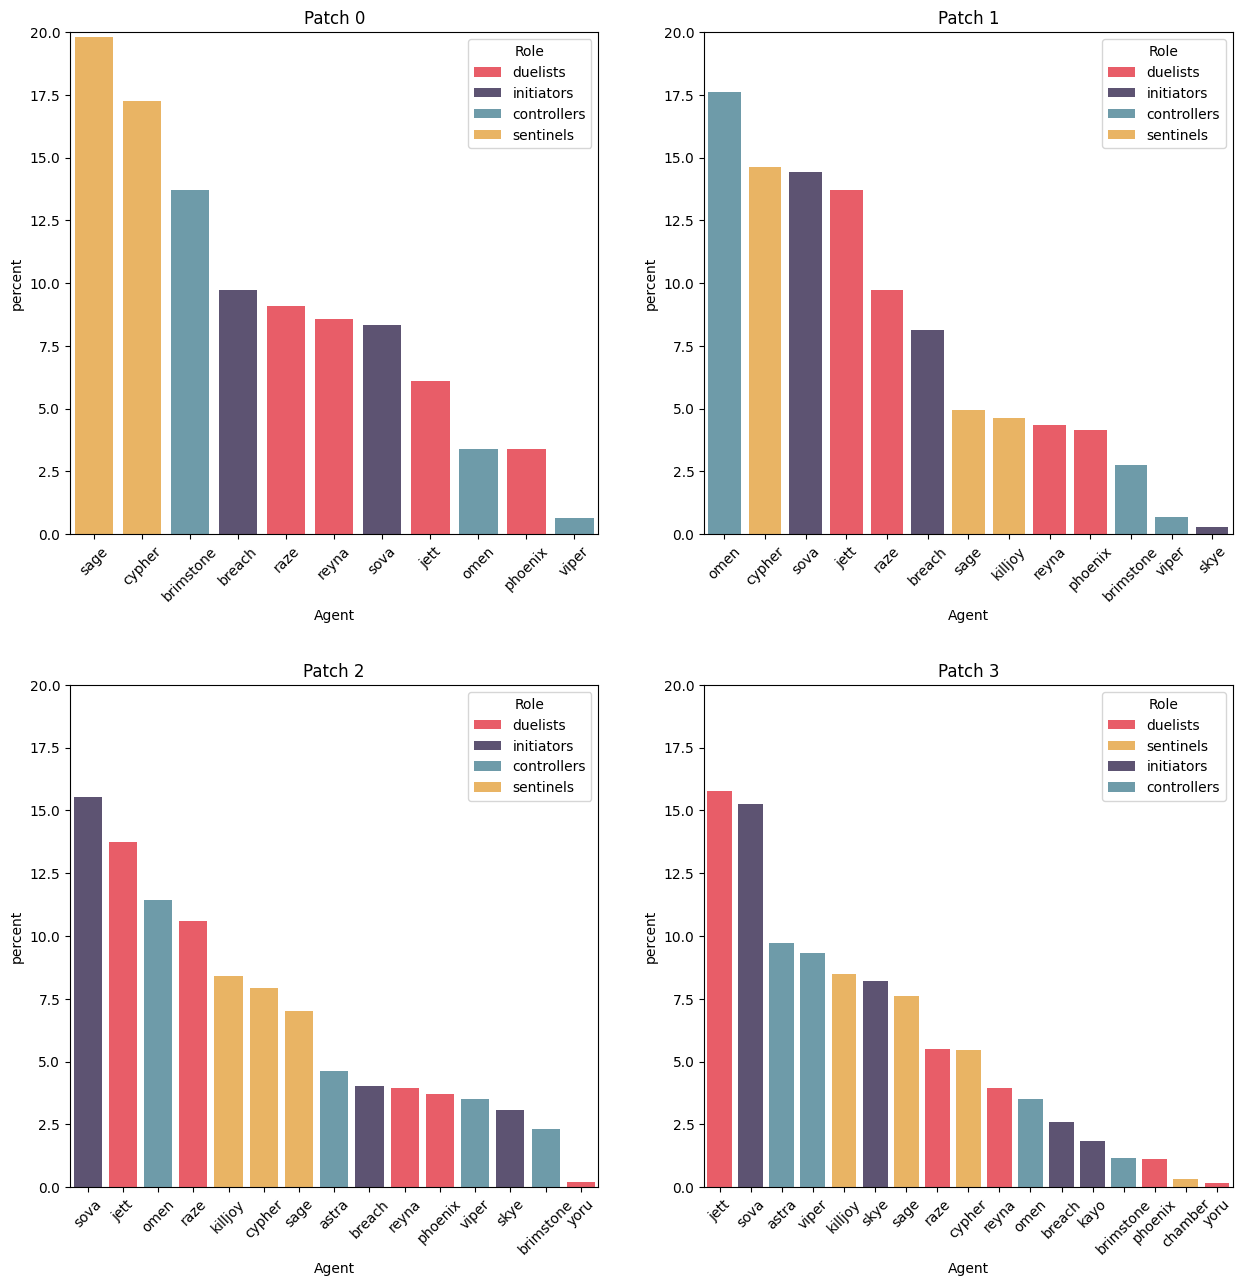

In [33]:
df_agent_patch = pd.merge(
    df_matches_games_scores[['Patch', 'Agent']],
    df_agent[['Agent', 'Role']],
    on='Agent')

patch_nums = sorted(df_agent_patch['Patch'].unique().astype(int))

lst_df_agent_patch = [
    df_agent_patch.query(f'Patch == "{patch_num}"') for patch_num in patch_nums
]

# Countplot
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)
axes = [(0, 0), (0, 1), (1, 0), (1, 1)]

for patch_num in patch_nums:
    current_axs = axs[axes[patch_num]]
    sns.countplot(lst_df_agent_patch[patch_num], x='Agent', hue='Role', ax=current_axs,
                  stat='percent', palette=palette_agent_role, order=lst_df_agent_patch[patch_num]['Agent'].value_counts().index)
    
    # Menyesuaikan plot
    current_axs.set_title(f'Patch {patch_num}')
    current_axs.tick_params(axis='x', labelrotation=45)
    current_axs.set_ylim(0, 20)

Distribusi Agent yang digunakan oleh pemain untuk setiap Patch 0.X, 1.X, 2.X, dan 3.X cukup bervariasi. Berdasarkan data di atas, kita mengetahui bahwa masing-masing patch memiliki `Agent` yang paling sering digunakan dalam pertandingan. Distribusi agent berdasarkan `Patch` di atas menandakan bahwa terdapat "meta" pada setiap `Patch` berkaitan dengan pemilihan agent. Meta yang berkaitan dengan `Agent` adalah `Agent` yang paling sering dipilih oleh tim dalam suatu pertandingan untuk meningkatkan kemungkinan tim untuk memenangkan pertandingan. Agent tersebut dipilih karena memiliki keuntungan tertentu (sepeti kemampuan) pada `Patch` tertentu. Agent-agent dengan persentase tertinggi untuk setiap `Patch` adalah sebagai berikut.

1. Patch 1: sage
2. Patch 2: omen
3. Patch 3: sova
4. Patch 4: jett

> Perhatikan bahwa pada `Patch` tertentu, kemampuan suatu `Agent` dapat berubah.

##### Jumlah Agent berdasarkan Patch

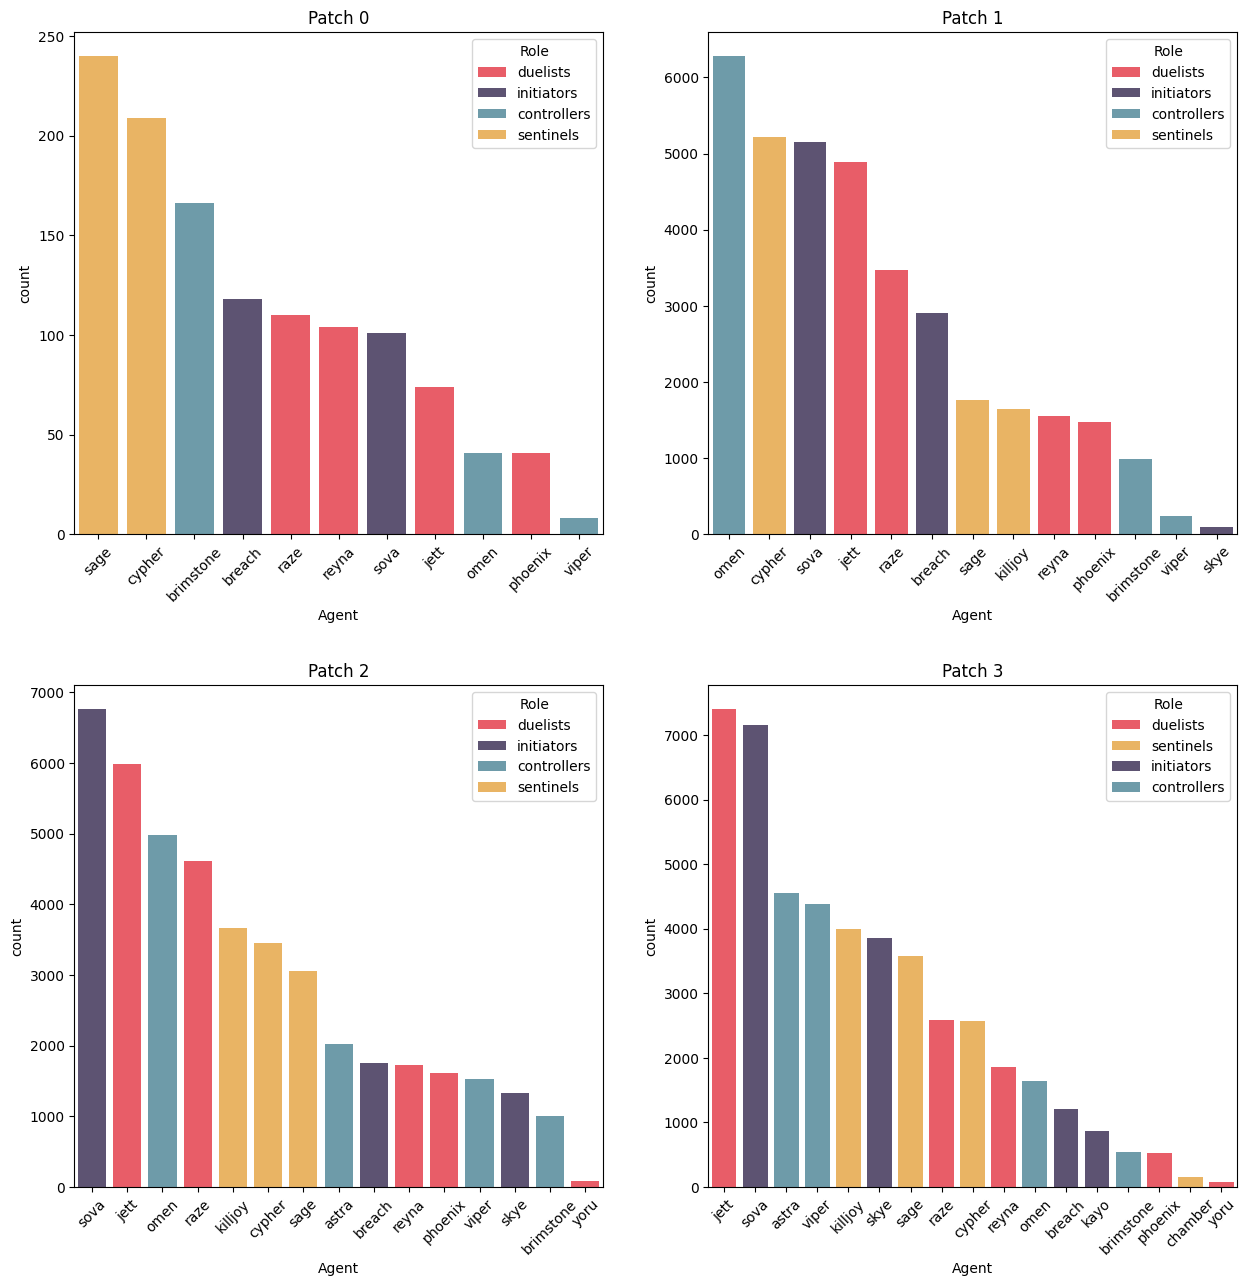

In [34]:
# Countplot
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)
axes = [(0, 0), (0, 1), (1, 0), (1, 1)]

for patch_num in patch_nums:
    current_axs = axs[axes[patch_num]]
    sns.countplot(lst_df_agent_patch[patch_num], x='Agent', hue='Role', ax=current_axs,
                  stat='count', palette=palette_agent_role, order=lst_df_agent_patch[patch_num]['Agent'].value_counts().index)

    # Menyesuaikan plot
    current_axs.set_title(f'Patch {patch_num}')
    current_axs.tick_params(axis='x', labelrotation=45)

Distribusi Agent yang digunakan oleh pemain untuk setiap Patch 0.X, 1.X, 2.X, dan 3.X cukup bervariasi. Berdasarkan data di atas, kita mengetahui bahwa masing-masing patch memiliki `Agent` yang paling sering digunakan dalam pertandingan. Distribusi agent berdasarkan `Patch` di atas menandakan bahwa terdapat "meta" pada setiap `Patch` berkaitan dengan pemilihan agent. Meta yang berkaitan dengan `Agent` adalah `Agent` yang paling sering dipilih oleh tim dalam suatu pertandingan untuk meningkatkan kemungkinan tim untuk memenangkan pertandingan. Agent tersebut dipilih karena memiliki keuntungan tertentu (sepeti kemampuan) pada `Patch` tertentu. Agent-agent dengan persentase tertinggi untuk setiap `Patch` adalah sebagai berikut.

1. Patch 1: sage
2. Patch 2: omen
3. Patch 3: sova
4. Patch 4: jett

> Perhatikan bahwa pada `Patch` tertentu, kemampuan suatu `Agent` dapat berubah.

##### Trend Agent berdasarkan `Patch`

In [35]:
df_agent_patch_trend = df_agent_patch.groupby('Agent').value_counts().reset_index().sort_values(by=['Agent', 'Patch', 'Role'])

def convert_count_to_percent(row):
    return row['count'] / len(lst_df_agent_patch[int(row['Patch'])])

df_agent_patch_trend['percent'] = df_agent_patch_trend.apply(convert_count_to_percent, axis='columns')
df_agent_patch_trend.head()


,Agent,Patch,Role,count,percent
1,astra,2,controllers,2020,0.046381
0,astra,3,controllers,4556,0.097019
5,breach,0,initiators,118,0.097360
2,breach,1,initiators,2904,0.081381
3,breach,2,initiators,1753,0.040251


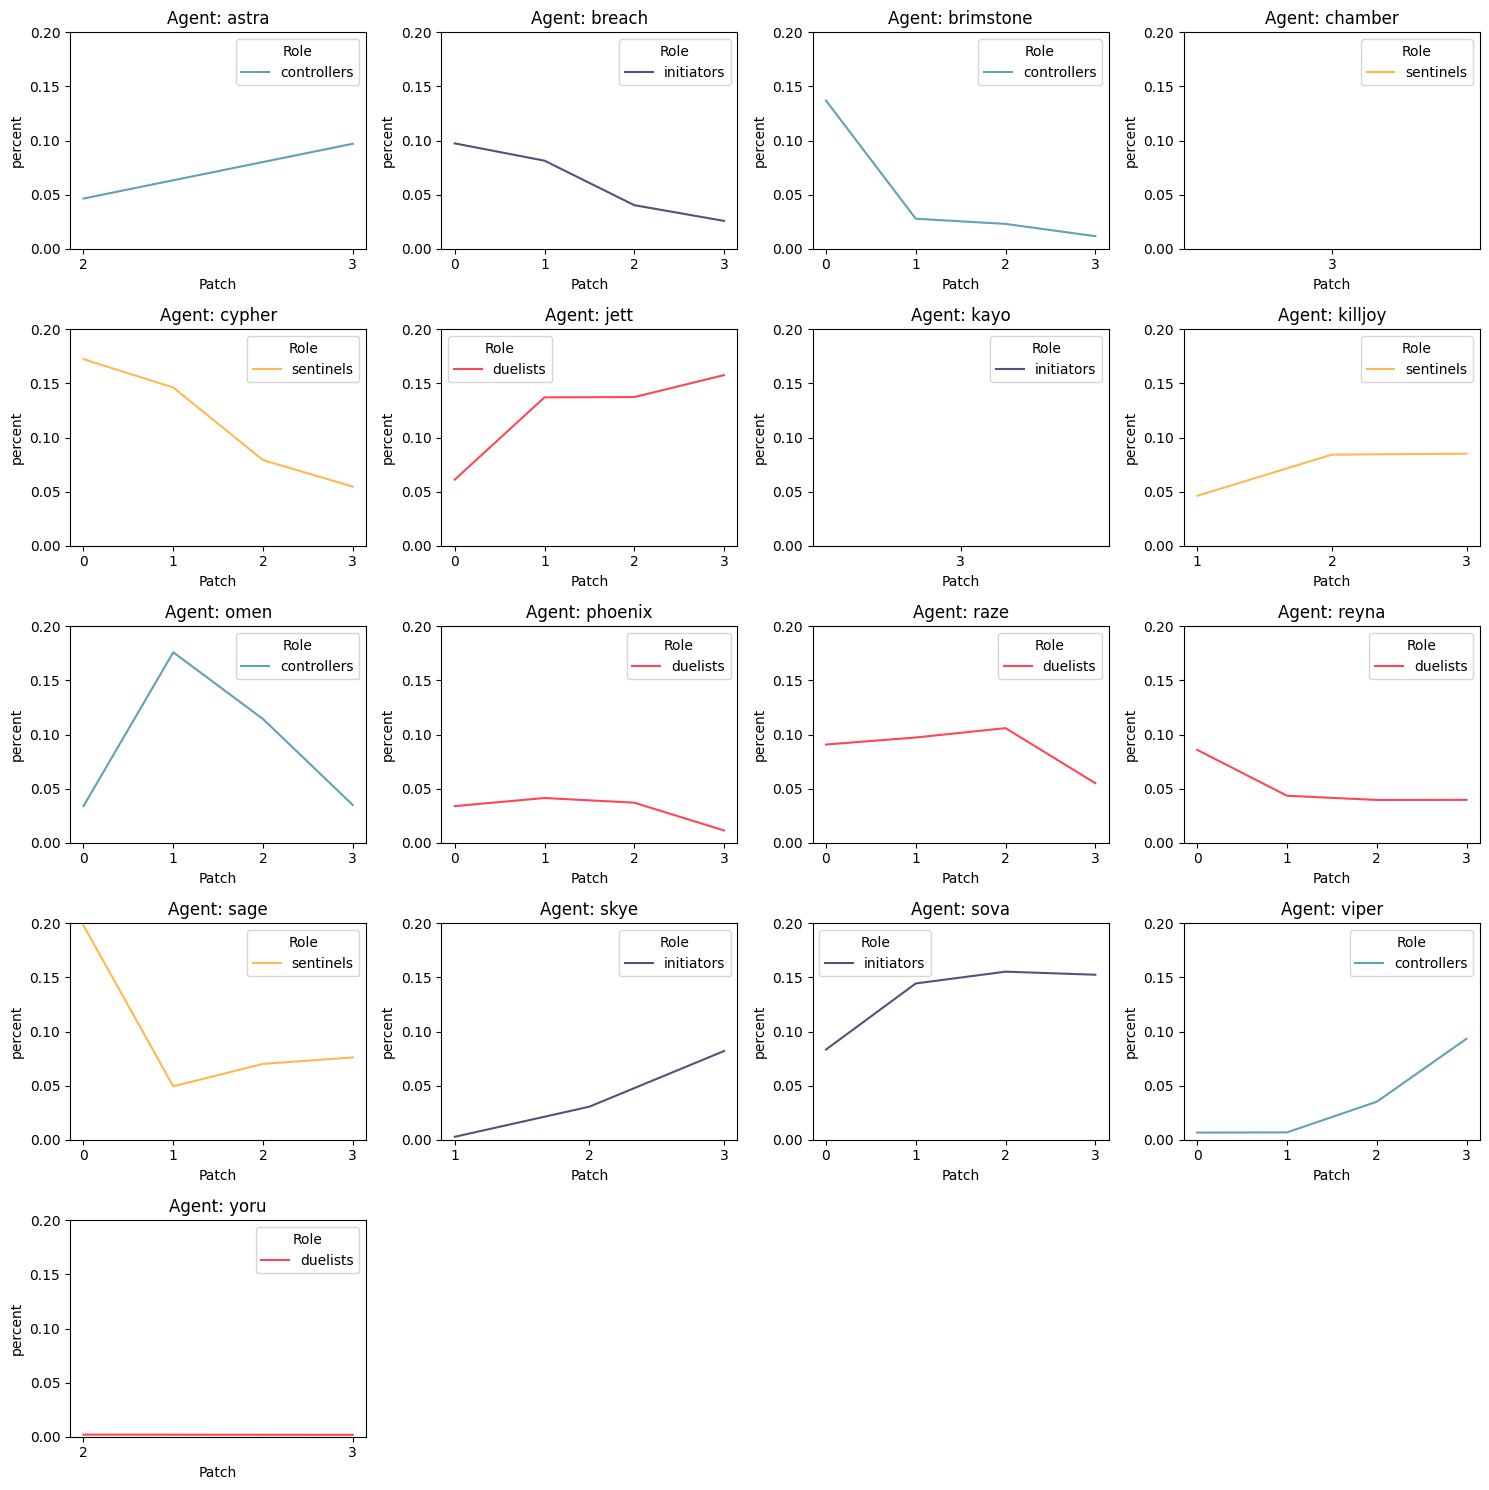

In [36]:
agents_name = df_agent['Agent'].sort_values().reset_index(drop=True)
axes = [
    (0, 0), (0, 1), (0, 2), (0, 3),
    (1, 0), (1, 1), (1, 2), (1, 3),
    (2, 0), (2, 1), (2, 2), (2, 3),
    (3, 0), (3, 1), (3, 2), (3, 3),
    (4, 0)
]

# Line chart
fig, axs = plt.subplots(5, 4, figsize=(15, 15))

for i in range(len(agents_name)):
    current_axs = axs[axes[i]]
    current_df_agent = df_agent_patch_trend.query(
        f'Agent == "{agents_name[i]}"')
    sns.lineplot(data=current_df_agent, x='Patch', y='percent', ax=current_axs, hue='Role', palette=palette_agent_role)

    # Menyesuaikan plot
    current_axs.set_title(f'Agent: {agents_name[i]}')
    current_axs.set_ylim(0, 0.2)

# Hapus subplots yang tidak terpakai
for ax in axs.flatten()[17:]:
    fig.delaxes(ax)

# Menyesuaikan layout
plt.tight_layout()

Berdasarkan line plot di atas, kita dapat mengetahui bahwa terdapat `Agent` yang mengalami penurunan pengguna pada patch
yang berbeda. `Agent` tersebut berupa breach, brimstone, cypher, omen, phoenix, raze, reyna, dan sage. Selain itu, ada agent yang mengalami kenaikan pengguna pada patch yang berbeda, seperti astra, jett, killjoy, omen, sage, skye, sova, dan viper.

> Perhatikan bahwa pada line plot kita menggunakan `percent` yang merepresentasikan persentase terpilihnya agent (*pick rate*) pada setiap patch untuk turnamen-turnamen yang ada. Hal ini dikarenakan data turnamen untuk masing-masing `Patch` berbeda sehingga kita perlu melakukan normalisasi, salah satunya dengan menggunakan `percent`/*agent pick rate*.

### Persebaran Nilai ACS Agent Berdasarkan Map

#### Informasi Kolom `ACS`

In [37]:
df_scores['ACS'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 128779 entries, 0 to 128778
Series name: ACS
Non-Null Count   Dtype  
--------------   -----  
128249 non-null  float64
dtypes: float64(1)
memory usage: 1006.2 KB


##### Jumlah Null Value

In [38]:
df_scores['ACS'].isnull().sum()

530

##### Persentase Null

In [39]:
util_scores.cek_null(df_scores)

                   Total    Percent
KAST_Percent      126142  97.952306
Defuses            10195   7.916663
OnevThree          10195   7.916663
Num_3Ks            10195   7.916663
Num_2Ks            10195   7.916663
OnevOne            10195   7.916663
Num_5Ks            10195   7.916663
OnevTwo            10195   7.916663
Num_4Ks            10195   7.916663
OnevFour           10195   7.916663
OnevFive           10195   7.916663
Econ               10195   7.916663
Plants             10195   7.916663
HS_Percent          9472   7.355236
FirstDeaths         9465   7.349801
FKFD_PlusMinus      9465   7.349801
ADR                 8875   6.891652
TeamAbbreviation    2016   1.565473
PlusMinus           1753   1.361247
Agent               1316   1.021906
FirstKills           530   0.411558
ACS                  530   0.411558
Assists              490   0.380497
Deaths               490   0.380497
Kills                490   0.380497


#### Pemrosesan Kolom ACS

Perhatikan bahwa kolom `ACS` memiliki 530 missing/null value. Kita perlu memperbaiki hal ini dengan melakukan *data imputation* berdasarkan kolom `Agent`. Hal ini dikarenakan nilai yang berada dalam kolom `ACS` dipengaruhi oleh siapa Agent yang dimainkan oleh pemain tersebut dan juga dikarenakan kita tidak memiliki rumus/formula untuk menghitung ACS maka kita mencari secara kasar saja.

##### Cek Distribusi

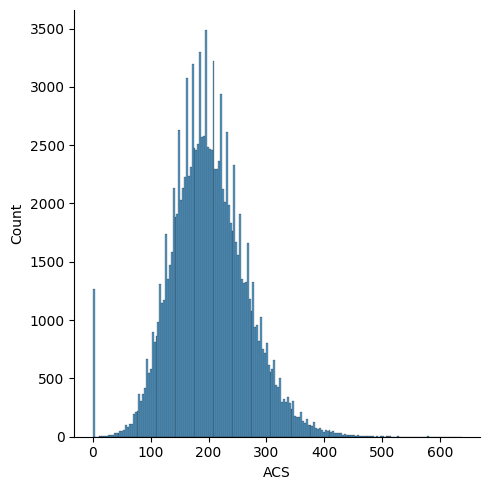

In [40]:
sns.displot(data=df_scores['ACS'])

<Axes: ylabel='ACS'>

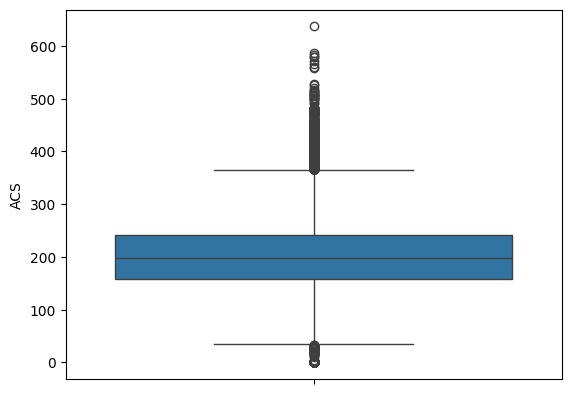

In [41]:
sns.boxplot(df_scores['ACS'])

Setelah kita lihat dari distribusi data yang ada, kita mendapatkan distribusi yang *skewed* dan memiliki banyak *outlier*. Oleh karena itu, untuk kolom `ACS` akan dilakukan *data imputation* dengan median ACS untuk setiap Agent.

##### Pencarian Median ACS Setiap Agent

In [42]:
acs_median = df_scores.groupby('Agent')['ACS'].median().reset_index()
acs_median

,Agent,ACS
0,astra,184.0
1,breach,170.0
2,brimstone,185.0
3,chamber,203.0
4,cypher,184.0
5,jett,226.0
6,kayo,186.0
7,killjoy,195.0
8,omen,185.0
9,phoenix,217.0


##### Imputasi Data untuk Kolom `ACS`

In [43]:
util_scores.acs_impute(df_scores, acs_median)

remerge_dataset()

##### Cek Null Value

In [44]:
df_scores['ACS'].isnull().sum()

99

Setelah melakukan *data imputation* kita masih memiliki beberapa nilai null. Hal ini dikarenakan data tersebut tidak memiliki Agent dan setelah ditelusuri kembali secara manual terlihat bahwa nilai ACS yang berhubungan juga 0 sehingga dapat kita abaikan.

#### Visualisasi Persebaran ACS

##### Persebaran ACS Agent

df_agent_acs = pd.merge(
    df_matches_games_scores[['Agent', 'ACS']],
    df_agent[['Agent', 'Role']], on='Agent'
)
lst_agents = sorted(df_agent_acs['Agent'].unique())

fig, axes = plt.subplots(5,4, figsize=(15,20))
axeses = [
    (0, 0), (0, 1), (0, 2), (0, 3),
    (1, 0), (1, 1), (1, 2), (1, 3),
    (2, 0), (2, 1), (2, 2), (2, 3),
    (3, 0), (3, 1), (3, 2), (3, 3),
    (4, 0)
]

for i in range(len(lst_agents)):

    current_axs = axes[axeses[i][0], axeses[i][1]]
    current_agent = df_agent_acs.query(f'Agent == "{lst_agents[i]}"')
    
    sns.kdeplot(data=current_agent, x='ACS', ax=current_axs)

    current_axs.set_title(f'Agent: {lst_agents[i]}')

for ax in axes.flatten()[17:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


Persebaran ACS untuk setiap Agent cukup mirip satu sama lainnya. Berdasarkan data di atas tergolong normal dan outlier pada data tersebut diabaikan. Hal ini dikarenakan nilai tersebut didapat dari perhitungan peforma pemain tersebut, yang mana tidak jarang ditemui jika ada pemain yang menonjol.

##### Persebaran ACS Terhadap Map

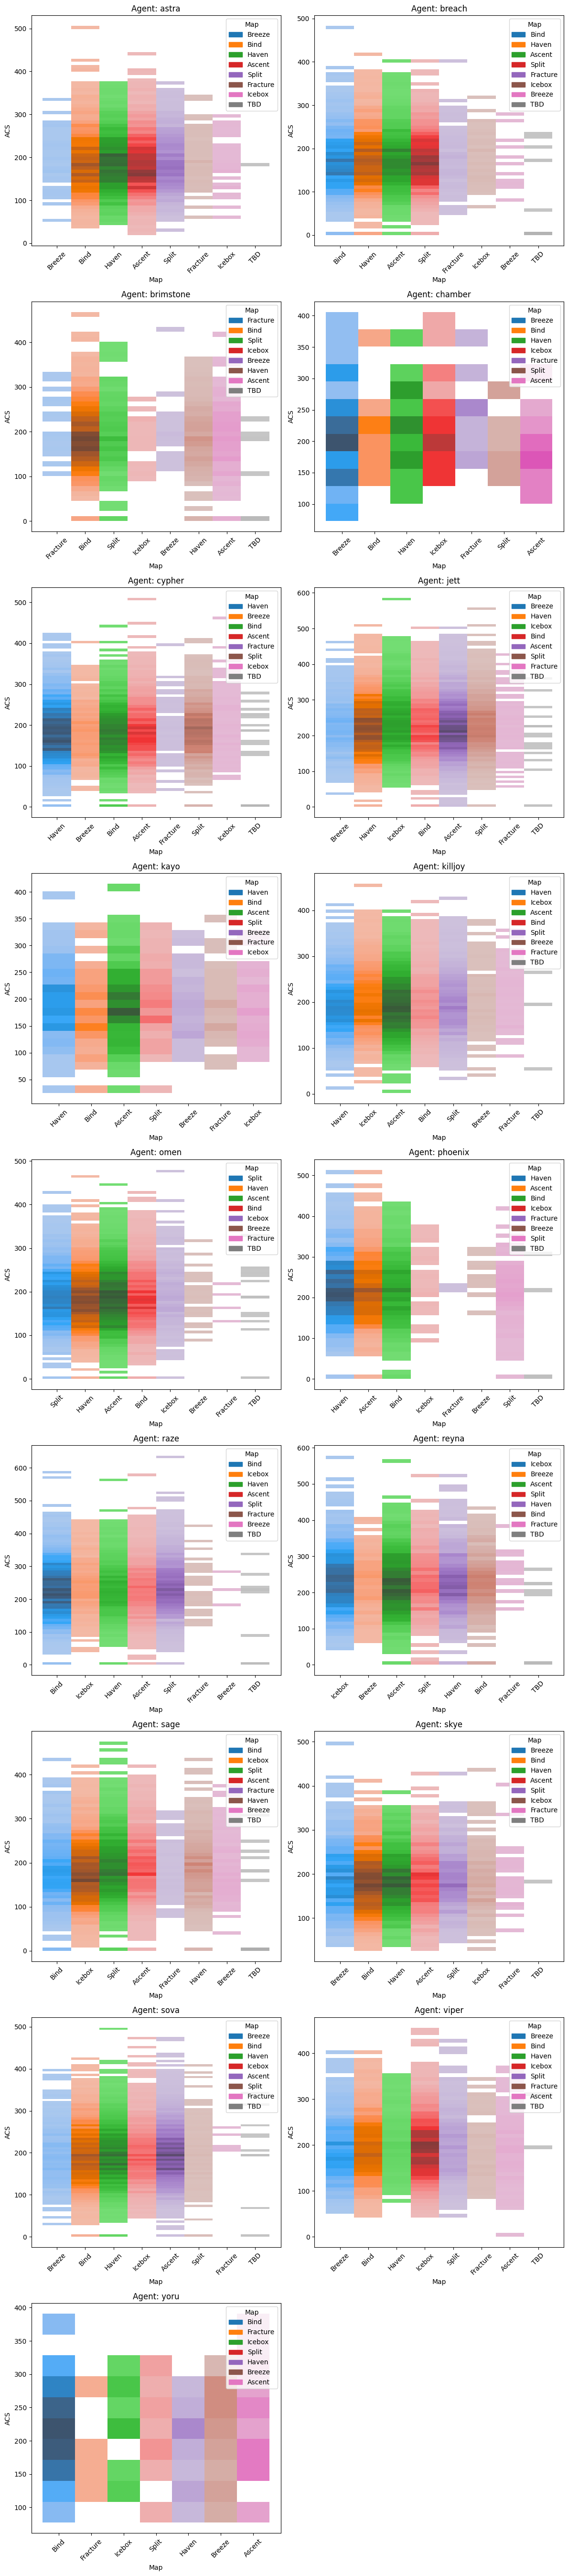

In [45]:
df_map_agent_acs = pd.merge(
    df_matches_games_scores[['Map', 'Agent', 'ACS']],
    df_agent[['Agent', 'Role']], on='Agent'
)

lst_agents = sorted(df_map_agent_acs['Agent'].unique())

num_agents = len(lst_agents)
num_columns = 2
num_rows = (num_agents + num_columns - 1) // num_columns  

fig, axes = plt.subplots(num_rows, num_columns, figsize=(12, num_rows * 6))

for idx, current_agent in enumerate(lst_agents):
    row_idx, col_idx = divmod(idx, num_columns)
    agent_data = df_map_agent_acs[df_map_agent_acs['Agent'] == current_agent]
    ax = axes[row_idx, col_idx]
    
    sns.histplot(data=agent_data, x='Map', y='ACS', hue='Map', ax=ax)
    
    ax.set_title(f'Agent: {current_agent}')
    ax.tick_params(axis='x', labelrotation=45)

if num_agents % num_columns != 0:
    for idx in range(num_agents, num_rows * num_columns):
        fig.delaxes(axes.flatten()[idx])

plt.tight_layout()

plt.show()

Dapat dilihat persebaran/distribusi dari ACS yang bervariasi setiap Map untuk setiap Agentnya. 

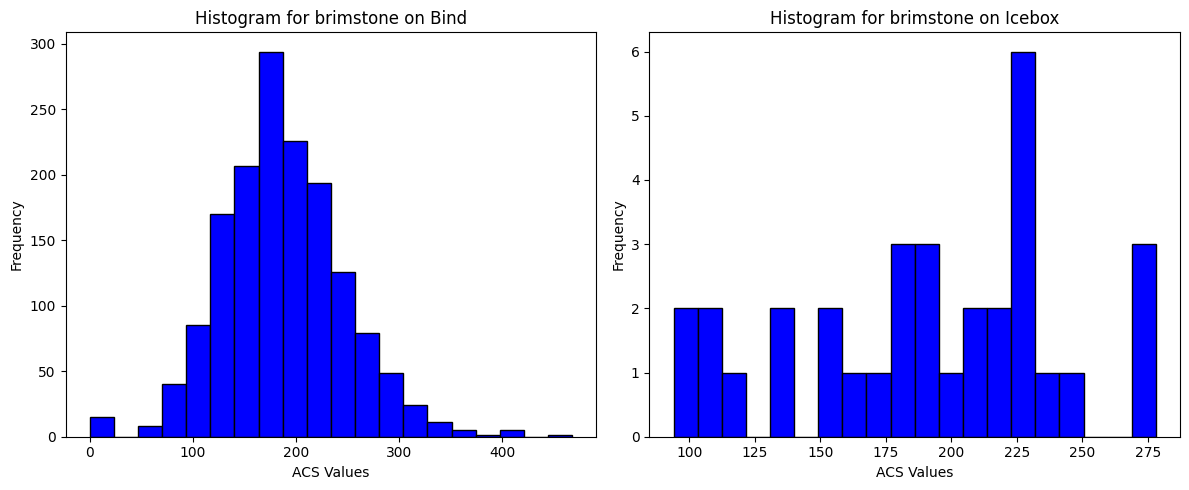

In [46]:
df_map_agent_acs = pd.merge(
    df_matches_games_scores[['Map', 'Agent', 'ACS']],
    df_agent[['Agent', 'Role']], on='Agent'
)

target_agent = 'brimstone'
target_maps = ['Bind', 'Icebox']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target_map in enumerate(target_maps):
    target_data = df_map_agent_acs[(df_map_agent_acs['Agent'] == target_agent) & (df_map_agent_acs['Map'] == target_map)]
    
    axes[i].hist(target_data['ACS'], bins=20, color='blue', edgecolor='black')
    
    axes[i].set_title(f'Histogram for {target_agent} on {target_map}')
    axes[i].set_xlabel('ACS Values')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()

plt.show()


Berdasarkan visualisasi di atas, kita dapat mengetahui bahwa distribusi ACS untuk setiap Agent dapat dipengaruhi oleh Map yang sedang dimainkan. Salah satu contoh tersebut adalah pada Agent 'Brimstone' yang memiliki distribusi ACS yang berbeda pada saat dia berada di Map 'Bind' dengan Map 'Icebox'.

### Problem C
#### Siapa tim yang paling banyak memenangkan pertandingan grand final dari sebuah Event?

Step 1: Menghitung jumlah kemunculan setiap tim pada pertandingan grand final

In [47]:
# Select only grand final stage
df_grand_final = df_matches.loc[df_matches['EventStage'].str.contains('Grand Final')]
# Select only necessary features
df_grand_final = df_grand_final.loc[:, ('MatchID', 'Team1', 'Team2', 'Team1_MapScore', 'Team2_MapScore')]

In [48]:
# Menghitung jumlah kemunculan sebuah team pada grand final sebagai team1
team1 = df_grand_final.value_counts("Team1")
team1_counts = pd.DataFrame(team1).reset_index()
team1_counts.columns = ['Team', 'Count']

# Menghitung jumlah kemunculan sebuah team pada grand final sebagai team2
team2 = df_grand_final['Team2'].value_counts()
team2_counts = pd.DataFrame(team2).reset_index()
team2_counts.columns = ['Team', 'Count']

In [50]:
# Merge kemunculan team sebagai team1 dan team2
team_counts = pd.merge(team1_counts, team2_counts, on=['Team'], suffixes=["_1", "_2"])
team_counts.columns = ["Team", "Team1_Count", "Team2_Count"]
team_counts.head()

,Team,Team1_Count,Team2_Count
0,Sentinels,8,1
1,Global Esports,7,2
2,Paper Rex,7,1
3,Wygers Argentina,6,1
4,Velocity Gaming,6,3


In [51]:
# Fungsi ini digunakan untuk menghitung total keseluruhan kemunculan team pada pertandignan grand final
def count_gf_matches(df:pd.DataFrame):
    return df['Team1_Count'] + df['Team2_Count']

# Hitung keseluruhan kemunculan team pada pertandingan grand final
team_counts.loc[:, "Total_Matches"] = team_counts.apply(count_gf_matches, axis=1)

In [52]:
team_counts = team_counts.drop(['Team1_Count', "Team2_Count"], axis=1)
team_counts = team_counts.sort_values("Total_Matches", ascending=False)
team_counts.head()

,Team,Total_Matches
5,Renegades,10
0,Sentinels,9
4,Velocity Gaming,9
1,Global Esports,9
2,Paper Rex,8


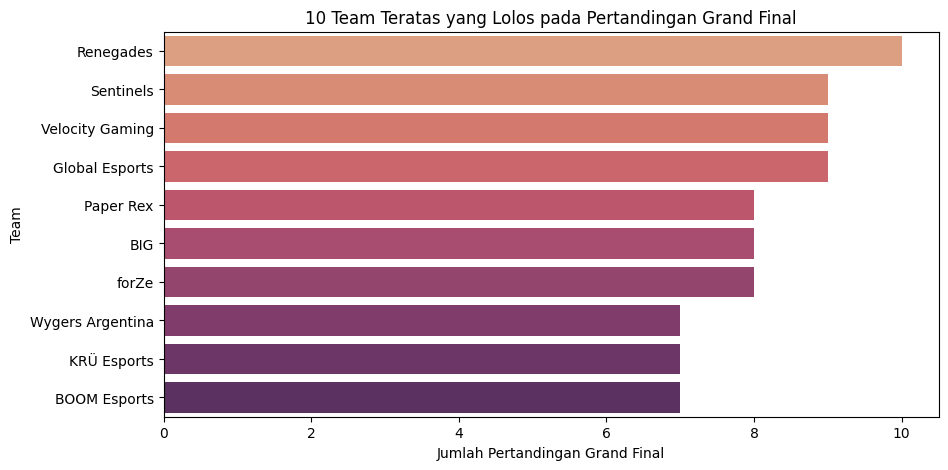

In [53]:
plt.figure(figsize=(10, 5))
sns.barplot(team_counts.iloc[0:10,:], x="Total_Matches", y= "Team", palette="flare", hue="Team")
plt.title("10 Team Teratas yang Lolos pada Pertandingan Grand Final")
plt.xlabel("Jumlah Pertandingan Grand Final")
plt.show()

Step 2: Menghitung team yang memiliki jumlah kemenangan paling banyak pada pertandingan grand final

In [54]:
# Determine the winner based on Map Scores
def winner(df:pd.DataFrame):
    if df['Team1_MapScore'] > df['Team2_MapScore']:
        return df['Team1']
    else:
        return df['Team2']

In [56]:
df_grand_final.loc[:, 'Winner'] = df_grand_final.apply(winner, axis=1)
team_winner_counts = df_grand_final['Winner'].value_counts()
print(f"Tim yang paling banyak memenangkan pertandingan pada Grand Final sebuah event adalah {team_winner_counts.index[0]}.")
print(f"Dengan jumlah kemenangan sebanyak {team_winner_counts.iloc[0]} kali.")

Tim yang paling banyak memenangkan pertandingan pada Grand Final sebuah event adalah Sentinels.
Dengan jumlah kemenangan sebanyak 9 kali.


In [57]:
team_winner_counts = team_winner_counts.reset_index()
team_winner_counts.columns = ["Team", "Winner_Count"]
team_winner_counts.head()

,Team,Winner_Count
0,Sentinels,9
1,BIG,8
2,forZe,7
3,Global Esports,7
4,Renegades,7


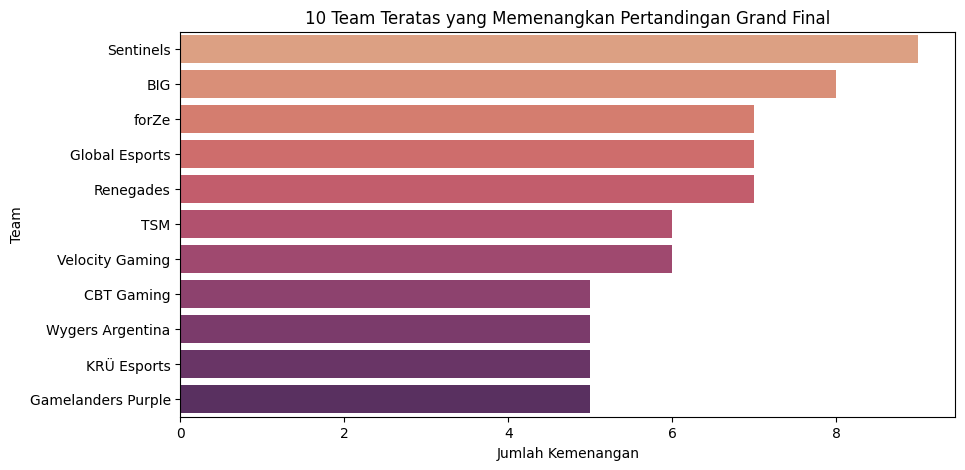

In [58]:
plt.figure(figsize=(10, 5))
sns.barplot(team_winner_counts.loc[0:10,:], x="Winner_Count", y= "Team", palette="flare", hue="Team")
plt.title("10 Team Teratas yang Memenangkan Pertandingan Grand Final")
plt.xlabel("Jumlah Kemenangan")
plt.show()

### Problem D
#### Komposisi tim seperti apakah yang paling banyak memenangkan pertandingan?

Step 1: Mencari komposisi tim berdasarkan agent

In [66]:
# Choose necessary features
df_d = df_matches_games_scores[['GameID', 'TeamAbbreviation', 'Team1_x', 'Team2_x', 'Winner', 'Agent']]
df_d.head()

,GameID,TeamAbbreviation,Team1_x,Team2_x,Winner,Agent
0,60894,Boos,Booster Seat Gaming,Pho Real,1,jett
1,60894,Boos,Booster Seat Gaming,Pho Real,1,chamber
2,60894,Boos,Booster Seat Gaming,Pho Real,1,sova
3,60894,Boos,Booster Seat Gaming,Pho Real,1,viper
4,60894,Boos,Booster Seat Gaming,Pho Real,1,skye


Pisahkan antara team 1 dan team 2 berdasarkan pemenang dari suatu `Game`

In [93]:
# Berdasarkan team1
team1_win = df_d[df_d["Winner"] == 1].groupby("GameID").head(5)
team1_win.iloc[::-1].head(10)

,GameID,TeamAbbreviation,Team1_x,Team2_x,Winner,Agent,Role
128648,67,2G4L,TooGoodForLan,Ferrari Peek,1,NaN,NaN
128647,67,2G4L,TooGoodForLan,Ferrari Peek,1,raze,duelists
128646,67,2G4L,TooGoodForLan,Ferrari Peek,1,sage,sentinels
128645,67,2G4L,TooGoodForLan,Ferrari Peek,1,cypher,sentinels
128644,67,2G4L,TooGoodForLan,Ferrari Peek,1,breach,initiators
128638,65,LEMO,LEMONn,OldTownRoad,1,NaN,NaN
128637,65,LEMO,LEMONn,OldTownRoad,1,NaN,NaN
128636,65,LEMO,LEMONn,OldTownRoad,1,NaN,NaN
128635,65,LEMO,LEMONn,OldTownRoad,1,breach,initiators
128634,65,LEMO,LEMONn,OldTownRoad,1,NaN,NaN


Terlihat bahwa terdapat beberapa agent yang bernilai `NaN` meski sudah dilakukan data imputation. Dalam kasus ini, kami memutuskan untuk meng-drop satu tim yang paling tidak terdapat satu agent yang bernilai `NaN`

In [94]:
# Filter berdasarkan gameID yang tidak memiliki agent yang bernilai null
team1_win = team1_win.groupby('GameID').filter(lambda x: not x['Agent'].isnull().any())
team1_win[['Agent']].isnull().sum()

Agent    0
dtype: int64

In [95]:
# Menggabungkan komposisi agent dari sebuah team dan dikelompokkan berdasarkan GameID
team1_win_grouped = team1_win[['GameID', 'Agent']].groupby("GameID")['Agent'].agg(lambda x: " ".join(x)).reset_index()
team1_win_grouped['Agent'] = team1_win_grouped['Agent'].apply(lambda agents: ' '.join(sorted(agents.split())))
team1_win_grouped.value_counts("Agent")

Agent
cypher jett omen raze sova          356
jett killjoy sage sova viper        329
cypher jett omen phoenix sova       317
breach cypher jett omen sova        303
jett reyna sage sova viper          281
                                   ... 
brimstone jett omen phoenix sova      1
brimstone jett killjoy skye yoru      1
brimstone jett killjoy sage skye      1
brimstone jett kayo sage sova         1
reyna sova viper                      1
Name: count, Length: 805, dtype: int64

In [96]:
# Berdasarkan team2
team2_win = df_d[df_d["Winner"] == 2].groupby("GameID").tail(5)
team2_win.iloc[::-1].head(10)

,GameID,TeamAbbreviation,Team1_x,Team2_x,Winner,Agent,Role
128723,13,NaN,Dignitas,JSD,2,NaN,NaN
128722,13,NaN,Dignitas,JSD,2,NaN,NaN
128721,13,NaN,Dignitas,JSD,2,NaN,NaN
128720,13,NaN,Dignitas,JSD,2,NaN,NaN
128719,13,NaN,Dignitas,JSD,2,NaN,NaN
128713,3,smok,smoke,Last Minute Heroes,2,cypher,sentinels
128712,3,smok,smoke,Last Minute Heroes,2,brimstone,controllers
128711,3,smok,smoke,Last Minute Heroes,2,breach,initiators
128710,3,smok,smoke,Last Minute Heroes,2,sage,sentinels
128709,3,smok,smoke,Last Minute Heroes,2,reyna,duelists


In [97]:
# Filter berdasarkan gameID yang tidak memiliki agent yang bernilai null
team2_win = team2_win.groupby('GameID').filter(lambda x: not x['Agent'].isnull().any())
team2_win[['Agent']].isnull().sum()

Agent    0
dtype: int64

In [98]:
# Menggabungkan komposisi agent dari sebuah team dan dikelompokkan berdasarkan GameID
team2_win_grouped = team2_win[['GameID', 'Agent']].groupby("GameID")['Agent'].agg(lambda x: " ".join(x)).reset_index()
team2_win_grouped['Agent'] = team2_win_grouped['Agent'].apply(lambda agents: ' '.join(sorted(agents.split())))
team2_win_grouped.value_counts("Agent")

Agent
jett reyna sage sova viper          108
jett killjoy sage sova viper         99
astra jett killjoy skye sova         96
cypher jett omen raze sova           95
cypher jett omen phoenix sova        84
                                   ... 
brimstone cypher raze skye sova       1
brimstone cypher raze sova viper      1
brimstone cypher skye sova viper      1
brimstone jett kayo reyna sova        1
raze sage skye sova viper             1
Name: count, Length: 483, dtype: int64

In [99]:
# Gabungkan hasil dari grouping team 1 dan team 2
team_compotition = pd.concat([team1_win_grouped, team2_win_grouped], ignore_index=True)
team_compotition = team_compotition.value_counts("Agent").reset_index()
team_compotition.head()

,Agent,count
0,cypher jett omen raze sova,451
1,jett killjoy sage sova viper,428
2,cypher jett omen phoenix sova,401
3,jett reyna sage sova viper,389
4,breach cypher jett omen sova,380


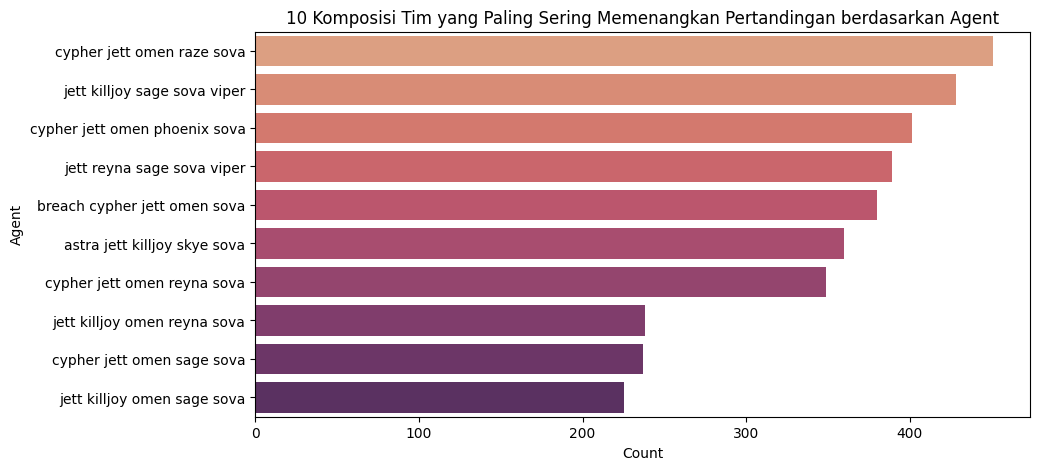

In [100]:
plt.figure(figsize=(10, 5))
sns.barplot(team_compotition.iloc[0:10,:], x="count", y= "Agent", palette="flare", hue="Agent")
plt.title("10 Komposisi Tim yang Paling Sering Memenangkan Pertandingan berdasarkan Agent")
plt.xlabel("Count")
plt.show()

Step 2: Mencari komposisi tim yang paling banyak memenangkan pertandingan berdasarkan role dari agent

In [101]:
# Menambahkan kolom role 
role_encoder = dict(zip(df_agent_role['Agent'], df_agent_role['Role']))
team1_win.loc[:,'Role'] = team1_win.loc[:,'Agent'].replace(role_encoder)
team2_win.loc[:,'Role'] = team2_win.loc[:,'Agent'].replace(role_encoder)

In [104]:
# Menggabungkan komposisi role dari sebuah team dan dikelompokkan berdasarkan GameID
team1_win_grouped_by_role = team1_win[['GameID', 'Role']].groupby("GameID")['Role'].agg(lambda x: " ".join(x)).reset_index()
team1_win_grouped_by_role['Role'] = team1_win_grouped_by_role['Role'].apply(lambda role: ' '.join(sorted(role.split())))
team1_win_grouped_by_role.value_counts("Role").head()

Role
controllers duelists duelists initiators sentinels       3608
controllers duelists initiators initiators sentinels     2152
controllers duelists initiators sentinels sentinels      1839
controllers controllers duelists initiators sentinels     478
controllers duelists duelists sentinels sentinels         464
Name: count, dtype: int64

In [105]:
# Menggabungkan komposisi role dari sebuah team dan dikelompokkan berdasarkan GameID
team2_win_grouped_by_role = team2_win[['GameID', 'Role']].groupby("GameID")['Role'].agg(lambda x: " ".join(x)).reset_index()
team2_win_grouped_by_role['Role'] = team2_win_grouped_by_role['Role'].apply(lambda role: ' '.join(sorted(role.split())))
team2_win_grouped_by_role.value_counts("Role").head()

Role
controllers duelists duelists initiators sentinels       1086
controllers duelists initiators initiators sentinels      595
controllers duelists initiators sentinels sentinels       549
controllers controllers duelists initiators sentinels     156
controllers duelists duelists sentinels sentinels         156
Name: count, dtype: int64

In [106]:
# Gabungkan hasil grouping team 1 dan team 2
team_compotition_by_role = pd.concat([team1_win_grouped_by_role, team2_win_grouped_by_role], ignore_index=True)
team_compotition_by_role = team_compotition_by_role.value_counts("Role").reset_index()
team_compotition_by_role.head()

,Role,count
0,controllers duelists duelists initiators senti...,4694
1,controllers duelists initiators initiators sen...,2747
2,controllers duelists initiators sentinels sent...,2388
3,controllers controllers duelists initiators se...,634
4,controllers duelists duelists sentinels sentinels,620


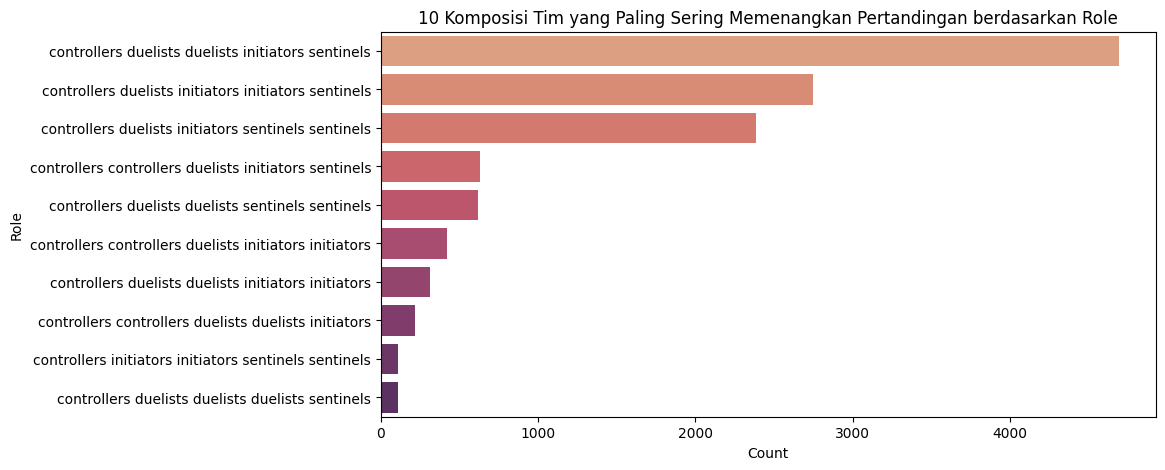

In [108]:
plt.figure(figsize=(10, 5))
sns.barplot(team_compotition_by_role.iloc[0:10,:], x="count", y= "Role", palette="flare", hue="Role")
plt.title("10 Komposisi Tim yang Paling Sering Memenangkan Pertandingan berdasarkan Role")
plt.xlabel("Count")
plt.show()

## Data Preprocessing

## Modeling and Evaluation

## Sumber Referensi

1. https://en.wikipedia.org/wiki/Valorant
2. https://www.ign.com/wikis/valorant/Concepts:_Roles_in_Valorant
3. https://valorant.fandom.com/wiki/Patch_Notes